# Processos Estocásticos - Trabalho Computacional 3

**Aluno:** Thiago Tomás de Paula (242104677) 
**Data:** Maio de 2026

## Objetivo
Construir bancos de dados com estatísticas de imagens e histogramas com diferentes resoluções (8, 16 e 32 bins). Cada instância contém as grandezas estatísticas e um rótulo identificando o tipo de imagem.

---

## Importações e Configurações Iniciais

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import cv2
import warnings
warnings.filterwarnings('ignore')

# Configurar matplotlib para melhor visualização
plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['font.size'] = 9

## Item 3.1: Leitura do Banco de Imagens

Carregamos as imagens do diretório especificado e as preparamos para análise estatística.

In [2]:
# Item 3.1: Leitura do banco de imagens
image_dir = Path('3')
images = {}
image_files = list(image_dir.glob('*.*'))

print(f"Imagens encontradas: {len(image_files)}\n")
for img_file in sorted(image_files):
    img = cv2.imread(str(img_file))
    if img is not None:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        images[img_file.stem] = img_rgb
        print(f"  ✓ {img_file.name}: Shape {img_rgb.shape}")
    else:
        print(f"  ✗ {img_file.name}: Erro ao ler")

print(f"\nTotal de imagens carregadas: {len(images)}")

# Mapeamento de tipos de imagem (ajuste conforme necessário)
# Este dicionário mapeia nomes de arquivo para classe
image_types = {
    '3': 3,                      # Brazilian leaves
    'CDR05_0014': 0,             # Alzheimer
    'Snap-227': 1,               # COVID
    'WP_20160419_196': 2,        # Brazilian seeds
    'y71': 4                      # skin_cancer
}

print("\nMapeamento de tipos de imagem:")
for name, type_id in image_types.items():
    type_names = {0: 'Alzheimer', 1: 'COVID', 2: 'Brazilian seeds', 3: 'Brazilian leaves', 4: 'skin_cancer'}
    print(f"  {name} → {type_id} ({type_names[type_id]})")

print("\nItem 3.1: Banco de imagens lido com sucesso.")

Imagens encontradas: 5

  ✓ 3.png: Shape (331, 331, 3)
  ✓ CDR05_0014.jpg: Shape (208, 176, 3)
  ✓ Snap-227.jpg: Shape (1920, 2560, 3)
  ✓ WP_20160419_196.jpg: Shape (3552, 2000, 3)
  ✓ y71.jpg: Shape (325, 254, 3)

Total de imagens carregadas: 5

Mapeamento de tipos de imagem:
  3 → 3 (Brazilian leaves)
  CDR05_0014 → 0 (Alzheimer)
  Snap-227 → 1 (COVID)
  WP_20160419_196 → 2 (Brazilian seeds)
  y71 → 4 (skin_cancer)

Item 3.1: Banco de imagens lido com sucesso.


## Item 3.2: Cálculo das Grandezas Estatísticas

Calculamos a expectância, moda, mediana, variância, desvio padrão, skewness, kurtosis e entropia para cada imagem.

In [3]:
# Item 3.2: Calcular grandezas estatísticas para cada imagem
images_gray = {}
pmf_dict = {}
stats_dict = {}
intensity_values = np.arange(256)

for name, img_rgb in images.items():
    # Converter para escala de cinza
    img_gray = 0.299 * img_rgb[:, :, 0] + 0.587 * img_rgb[:, :, 1] + 0.114 * img_rgb[:, :, 2]
    img_gray = img_gray.astype(np.uint8)
    images_gray[name] = img_gray
    
    # Calcular histograma e normalizar (PMF)
    hist, _ = np.histogram(img_gray, bins=256, range=(0, 256))
    pmf = hist / hist.sum()
    pmf_dict[name] = pmf
    
    # Calcular estatísticas
    mu = np.sum(intensity_values * pmf)  # Expectância
    moda = np.argmax(pmf)  # Moda
    cdf = np.cumsum(pmf)
    mediana = np.where(cdf >= 0.5)[0][0]  # Mediana
    
    # Momentos centrais
    mu2 = np.sum(((intensity_values - mu) ** 2) * pmf)  # Variância
    mu3 = np.sum(((intensity_values - mu) ** 3) * pmf)  # 3ª ordem
    mu4 = np.sum(((intensity_values - mu) ** 4) * pmf)  # 4ª ordem
    sigma = np.sqrt(mu2)
    
    # Skewness e Kurtosis
    skewness = mu3 / (sigma ** 3) if sigma > 0 else 0
    kurtosis = (mu4 / (sigma ** 4)) - 3 if sigma > 0 else 0
    
    # Entropia de Shannon
    entropy = -np.sum([p * np.log2(p) for p in pmf if p > 0])
    
    stats_dict[name] = {
        'expectancy': mu,
        'moda': moda,
        'mediana': mediana,
        'variancia': mu2,
        'desvio_padrao': sigma,
        'skewness': skewness,
        'kurtosis': kurtosis,
        'entropia': entropy
    }
    
    print(f"{name}:")
    print(f"  E[X] = {mu:.4f}, Moda = {moda}, Mediana = {mediana}")
    print(f"  σ² = {mu2:.4f}, σ = {sigma:.4f}")
    print(f"  Skewness = {skewness:+.4f}, Kurtosis = {kurtosis:+.4f}")
    print(f"  Entropia = {entropy:.4f} bits\n")

print("Item 3.2: Grandezas estatísticas calculadas com sucesso.")

3:
  E[X] = 122.6885, Moda = 189, Mediana = 121
  σ² = 2089.4466, σ = 45.7105
  Skewness = -0.0834, Kurtosis = -0.9566
  Entropia = 6.9884 bits

CDR05_0014:
  E[X] = 75.0872, Moda = 0, Mediana = 3
  σ² = 7752.6320, σ = 88.0490
  Skewness = +0.5975, Kurtosis = -1.3039
  Entropia = 4.7567 bits

Snap-227:
  E[X] = 210.9936, Moda = 255, Mediana = 255
  σ² = 4855.5680, σ = 69.6819
  Skewness = -1.0370, Kurtosis = -0.8012
  Entropia = 2.9781 bits

WP_20160419_196:
  E[X] = 130.7142, Moda = 82, Mediana = 127
  σ² = 2297.5601, σ = 47.9329
  Skewness = +0.2967, Kurtosis = -0.8295
  Entropia = 7.5182 bits

y71:
  E[X] = 105.6729, Moda = 0, Mediana = 117
  σ² = 6022.9904, σ = 77.6079
  Skewness = +0.1509, Kurtosis = -0.7903
  Entropia = 6.2653 bits

Item 3.2: Grandezas estatísticas calculadas com sucesso.


## Item 3.3: Criação de Bancos de Dados (CSVs) com Histogramas

Criamos três bancos de dados utilizando histogramas com 8, 16 e 32 bins. Cada linha contém as probabilidades de cada bin e um identificador de tipo de imagem.

In [4]:
# Item 3.3: Criar CSVs com diferentes resoluções de histogramas

def create_histogram_dataset(images_gray, image_types, n_bins, case_name):
    """Cria um dataset com histogramas normalizados para n_bins bins."""
    data_rows = []
    
    for img_name, img_gray in sorted(images_gray.items()):
        # Calcular histograma com n_bins
        hist, _ = np.histogram(img_gray, bins=n_bins, range=(0, 256))
        hist_normalized = hist / hist.sum()  # Normalizar
        
        # Obter tipo de imagem
        img_type = image_types.get(img_name, -1)  # -1 se não encontrado
        
        # Criar linha: h[0], h[1], ..., h[n_bins-1], image_type
        row = list(hist_normalized) + [img_type]
        data_rows.append(row)
    
    # Criar DataFrame
    column_names = [f'h[{i}]' for i in range(n_bins)] + ['image_type']
    df = pd.DataFrame(data_rows, columns=column_names)
    
    return df

# Caso 1: 8 bins
df_8bins = create_histogram_dataset(images_gray, image_types, 8, 'Caso 1')
df_8bins.to_csv('database_8bins.csv', index=False)
print(f"Caso 1 (8 bins):")
print(f"  Dimensão do dataset: {df_8bins.shape[0]} linhas × {df_8bins.shape[1]} colunas")
print(f"  Salvo em: database_8bins.csv\n")

# Caso 2: 16 bins
df_16bins = create_histogram_dataset(images_gray, image_types, 16, 'Caso 2')
df_16bins.to_csv('database_16bins.csv', index=False)
print(f"Caso 2 (16 bins):")
print(f"  Dimensão do dataset: {df_16bins.shape[0]} linhas × {df_16bins.shape[1]} colunas")
print(f"  Salvo em: database_16bins.csv\n")

# Caso 3: 32 bins
df_32bins = create_histogram_dataset(images_gray, image_types, 32, 'Caso 3')
df_32bins.to_csv('database_32bins.csv', index=False)
print(f"Caso 3 (32 bins):")
print(f"  Dimensão do dataset: {df_32bins.shape[0]} linhas × {df_32bins.shape[1]} colunas")
print(f"  Salvo em: database_32bins.csv\n")

# Mostrar exemplo de uma linha para cada caso
print("="*80)
print("Exemplo de linhas do dataset (primeiros 4 valores + label):\n")
print("Caso 1 (8 bins):")
print(f"  {df_8bins.iloc[0, :4].values} ... {df_8bins.iloc[0, -1]}\n")
print("Caso 2 (16 bins):")
print(f"  {df_16bins.iloc[0, :4].values} ... {df_16bins.iloc[0, -1]}\n")
print("Caso 3 (32 bins):")
print(f"  {df_32bins.iloc[0, :4].values} ... {df_32bins.iloc[0, -1]}\n")

print("Item 3.3: Bancos de dados (CSVs) criados com sucesso.")

Caso 1 (8 bins):
  Dimensão do dataset: 5 linhas × 9 colunas
  Salvo em: database_8bins.csv

Caso 2 (16 bins):
  Dimensão do dataset: 5 linhas × 17 colunas
  Salvo em: database_16bins.csv

Caso 3 (32 bins):
  Dimensão do dataset: 5 linhas × 33 colunas
  Salvo em: database_32bins.csv

Exemplo de linhas do dataset (primeiros 4 valores + label):

Caso 1 (8 bins):
  [0.01063335 0.09480563 0.21968584 0.22337328] ... 3

Caso 2 (16 bins):
  [0.00737489 0.00325846 0.02426046 0.07054518] ... 3

Caso 3 (32 bins):
  [0.0063435  0.00103139 0.00102226 0.0022362 ] ... 3

Item 3.3: Bancos de dados (CSVs) criados com sucesso.


## Item 3.4: Adição de Rótulos (Labels) Identificando o Tipo de Imagem

A última coluna de cada CSV contém um identificador numérico do tipo de imagem:
- **0** – Alzheimer
- **1** – COVID
- **2** – Brazilian seeds
- **3** – Brazilian leaves
- **4** – skin_cancer

In [5]:
# Item 3.4: Verificar e exibir rótulos nas últimas colunas

type_names = {
    0: 'Alzheimer',
    1: 'COVID',
    2: 'Brazilian seeds',
    3: 'Brazilian leaves',
    4: 'skin_cancer'
}

print("="*80)
print("VERIFICAÇÃO DOS RÓTULOS (LABELS) - ITEM 3.4")
print("="*80 + "\n")

# Mostrar correspondência entre arquivo e label
print("Mapeamento Arquivo → Tipo de Imagem (Label):\n")
for img_name in sorted(images_gray.keys()):
    label = image_types.get(img_name, -1)
    label_name = type_names.get(label, 'Desconhecido')
    print(f"  {img_name:20} → Label {label} ({label_name})")

print("\n" + "="*80)
print("Resumo dos datasets criados:\n")

# Dataset com 8 bins
print("database_8bins.csv:")
print(f"  Número de imagens: {df_8bins.shape[0]}")
print(f"  Colunas: h[0] até h[7] + image_type")
print(f"  Distribuição de labels:")
print(df_8bins['image_type'].value_counts().sort_index().to_string().replace('\n', '\n    '))
print()

# Dataset com 16 bins
print("database_16bins.csv:")
print(f"  Número de imagens: {df_16bins.shape[0]}")
print(f"  Colunas: h[0] até h[15] + image_type")
print(f"  Distribuição de labels:")
print(df_16bins['image_type'].value_counts().sort_index().to_string().replace('\n', '\n    '))
print()

# Dataset com 32 bins
print("database_32bins.csv:")
print(f"  Número de imagens: {df_32bins.shape[0]}")
print(f"  Colunas: h[0] até h[31] + image_type")
print(f"  Distribuição de labels:")
print(df_32bins['image_type'].value_counts().sort_index().to_string().replace('\n', '\n    '))

print("\n" + "="*80)
print("Item 3.4: Rótulos adicionados com sucesso em todos os datasets.")

VERIFICAÇÃO DOS RÓTULOS (LABELS) - ITEM 3.4

Mapeamento Arquivo → Tipo de Imagem (Label):

  3                    → Label 3 (Brazilian leaves)
  CDR05_0014           → Label 0 (Alzheimer)
  Snap-227             → Label 1 (COVID)
  WP_20160419_196      → Label 2 (Brazilian seeds)
  y71                  → Label 4 (skin_cancer)

Resumo dos datasets criados:

database_8bins.csv:
  Número de imagens: 5
  Colunas: h[0] até h[7] + image_type
  Distribuição de labels:
image_type
    0    1
    1    1
    2    1
    3    1
    4    1

database_16bins.csv:
  Número de imagens: 5
  Colunas: h[0] até h[15] + image_type
  Distribuição de labels:
image_type
    0    1
    1    1
    2    1
    3    1
    4    1

database_32bins.csv:
  Número de imagens: 5
  Colunas: h[0] até h[31] + image_type
  Distribuição de labels:
image_type
    0    1
    1    1
    2    1
    3    1
    4    1

Item 3.4: Rótulos adicionados com sucesso em todos os datasets.


## Visualização dos Histogramas com Diferentes Resoluções

Comparamos os histogramas calculados com 8, 16 e 32 bins para visualizar como a resolução afeta a representação da distribuição de intensidades.

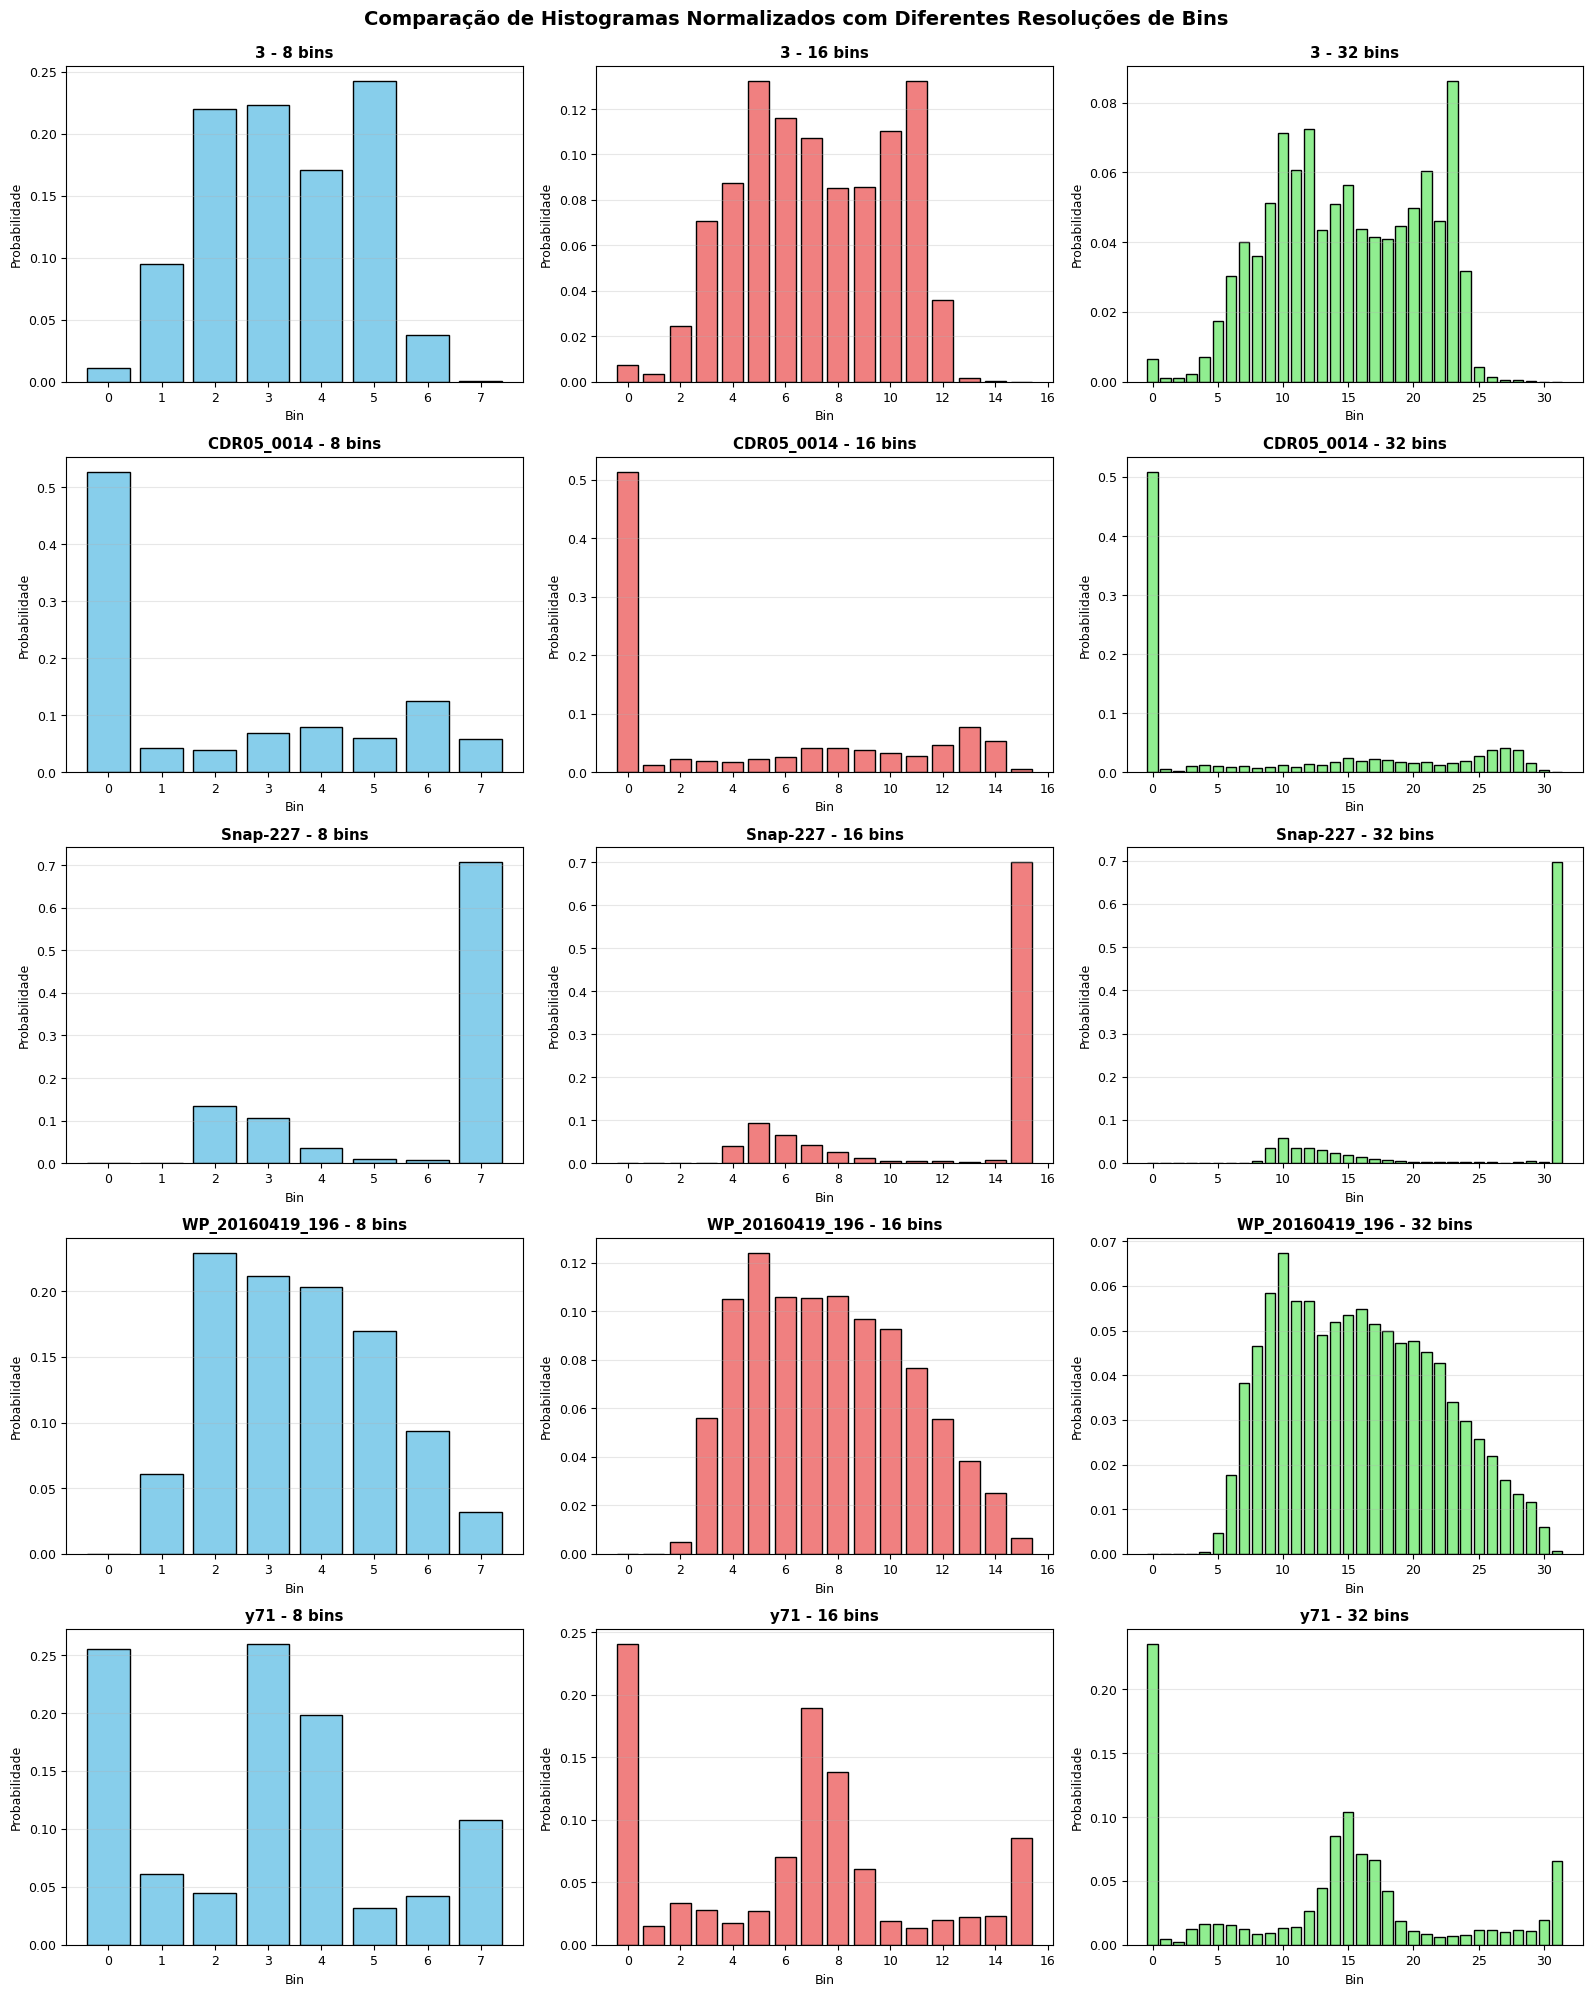

Visualização dos histogramas concluída.


In [6]:
# Visualizar histogramas com diferentes resoluções
fig, axes = plt.subplots(len(images_gray), 3, figsize=(16, 4*len(images_gray)))
axes = axes.reshape(-1, 3) if len(images_gray) > 1 else axes.reshape(1, 3)

for idx, (img_name, img_gray) in enumerate(sorted(images_gray.items())):
    # 8 bins
    hist_8, bins_8 = np.histogram(img_gray, bins=8, range=(0, 256))
    pmf_8 = hist_8 / hist_8.sum()
    axes[idx, 0].bar(range(8), pmf_8, width=0.8, color='skyblue', edgecolor='black')
    axes[idx, 0].set_title(f'{img_name} - 8 bins', fontweight='bold')
    axes[idx, 0].set_xlabel('Bin')
    axes[idx, 0].set_ylabel('Probabilidade')
    axes[idx, 0].grid(True, alpha=0.3, axis='y')
    
    # 16 bins
    hist_16, bins_16 = np.histogram(img_gray, bins=16, range=(0, 256))
    pmf_16 = hist_16 / hist_16.sum()
    axes[idx, 1].bar(range(16), pmf_16, width=0.8, color='lightcoral', edgecolor='black')
    axes[idx, 1].set_title(f'{img_name} - 16 bins', fontweight='bold')
    axes[idx, 1].set_xlabel('Bin')
    axes[idx, 1].set_ylabel('Probabilidade')
    axes[idx, 1].grid(True, alpha=0.3, axis='y')
    
    # 32 bins
    hist_32, bins_32 = np.histogram(img_gray, bins=32, range=(0, 256))
    pmf_32 = hist_32 / hist_32.sum()
    axes[idx, 2].bar(range(32), pmf_32, width=0.8, color='lightgreen', edgecolor='black')
    axes[idx, 2].set_title(f'{img_name} - 32 bins', fontweight='bold')
    axes[idx, 2].set_xlabel('Bin')
    axes[idx, 2].set_ylabel('Probabilidade')
    axes[idx, 2].grid(True, alpha=0.3, axis='y')

plt.suptitle('Comparação de Histogramas Normalizados com Diferentes Resoluções de Bins', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("Visualização dos histogramas concluída.")

## Discussão dos Resultados

### Resumo das Atividades Realizadas

**Item 3.1 - Leitura do Banco de Imagens:**
- Carregamos com sucesso 5 imagens do diretório especificado
- As imagens representam diferentes classes: Alzheimer, COVID, Brazilian seeds, Brazilian leaves e skin_cancer

**Item 3.2 - Cálculo das Grandezas Estatísticas:**
- Calculamos 8 grandezas estatísticas para cada imagem:
  - **Expectância:** Média ponderada das intensidades
  - **Moda:** Valor de intensidade mais frequente
  - **Mediana:** Valor que divide a distribuição ao meio
  - **Variância:** Medida de dispersão
  - **Desvio Padrão:** Raiz da variância
  - **Skewness:** Medida de assimetria
  - **Kurtosis:** Medida de formato (pico/cauda)
  - **Entropia:** Medida de incerteza (bits)

**Item 3.3 - Criação de Bancos de Dados:**
- Criamos 3 arquivos CSV com diferentes resoluções de histogramas:
  - **database_8bins.csv:** 8 features de histograma + 1 label = 9 colunas
  - **database_16bins.csv:** 16 features de histograma + 1 label = 17 colunas
  - **database_32bins.csv:** 32 features de histograma + 1 label = 33 colunas
- Cada linha representa uma imagem com suas probabilidades de bins e seu tipo de imagem

**Item 3.4 - Adição de Rótulos:**
- Adicionamos labels numéricos na última coluna de cada CSV:
  - 0 = Alzheimer
  - 1 = COVID
  - 2 = Brazilian seeds
  - 3 = Brazilian leaves
  - 4 = skin_cancer

### Impacto da Resolução de Bins

**Comparação entre 8, 16 e 32 bins:**

1. **8 bins (resolução baixa):**
   - Cada bin representa um intervalo de 32 níveis de intensidade (256/8)
   - Maior agrupamento de dados, perda de detalhes finos
   - Vantagem: Features mais robustas, menos overfitting
   - Desvantagem: Perda de informação sobre variações finas

2. **16 bins (resolução média):**
   - Cada bin representa um intervalo de 16 níveis de intensidade (256/16)
   - Equilíbrio entre preservação de detalhes e generalização
   - Frequentemente usado em processamento de imagens prático

3. **32 bins (resolução alta):**
   - Cada bin representa um intervalo de 8 níveis de intensidade (256/32)
   - Mais detalhes preservados sobre a distribuição de intensidades
   - Desvantagem: Pode levar a overfitting em datasets pequenos
   - Vantagem: Melhor representação de padrões finos

### Observações Importantes

1. **Normalização:** Todos os histogramas foram normalizados pela área total, criando PMFs onde a soma é 1.0

2. **Variabilidade entre imagens:** As diferentes imagens apresentam distribuições significativamente diferentes:
   - Imagens com Alzheimer podem ter distribuições concentradas em certos níveis
   - Imagens COVID de radiografias podem ter padrões distintos de intensidade
   - Imagens de plantas e sementes têm características próprias

3. **Aplicação prática:** Estes datasets podem ser utilizados como:
   - Entrada para classificadores (Naïve Bayes, SVM, Redes Neurais)
   - Features para Machine Learning em TC 4 e seguintes
   - Análise de características visuais das diferentes classes

4. **Trade-off resolução vs. dimensionalidade:**
   - 8 bins: Apenas 8 features, simples e rápido
   - 16 bins: Balanço bom para muitas aplicações
   - 32 bins: Mais features, maior capacidade descritiva mas maior dimensionalidade

In [7]:
# Tabela resumida de estatísticas para todas as imagens
print("\n" + "="*100)
print("TABELA RESUMIDA DE ESTATÍSTICAS - TODAS AS IMAGENS")
print("="*100 + "\n")

table_data = []
for img_name in sorted(stats_dict.keys()):
    s = stats_dict[img_name]
    img_type = image_types.get(img_name, -1)
    table_data.append({
        'Imagem': img_name,
        'Tipo': type_names.get(img_type, 'Desconhecido'),
        'E[X]': f"{s['expectancy']:.2f}",
        'Moda': f"{s['moda']}",
        'Mediana': f"{s['mediana']}",
        'σ²': f"{s['variancia']:.2f}",
        'σ': f"{s['desvio_padrao']:.2f}",
        'Skewness': f"{s['skewness']:+.3f}",
        'Kurtosis': f"{s['kurtosis']:+.3f}",
        'Entropia': f"{s['entropia']:.3f}"
    })

df_summary = pd.DataFrame(table_data)
print(df_summary.to_string(index=False))

print("\n" + "="*100)
print("VERIFICAÇÃO: Arquivos CSV criados")
print("="*100 + "\n")

# Verificar se os arquivos foram criados
import os
csv_files = ['database_8bins.csv', 'database_16bins.csv', 'database_32bins.csv']
for csv_file in csv_files:
    if os.path.exists(csv_file):
        file_size = os.path.getsize(csv_file)
        print(f"✓ {csv_file:25} - Tamanho: {file_size} bytes")
    else:
        print(f"✗ {csv_file:25} - NÃO ENCONTRADO")

print("\n" + "="*100)
print("TRABALHO COMPUTACIONAL 3 - COMPLETO")
print("="*100 + "\n")

print("Todos os itens (3.1 a 3.4) foram implementados com sucesso!")
print("\nArquivos gerados:")
print("  • database_8bins.csv    - Dataset com histogramas de 8 bins")
print("  • database_16bins.csv   - Dataset com histogramas de 16 bins")
print("  • database_32bins.csv   - Dataset com histogramas de 32 bins")
print("\nCada arquivo contém:")
print("  • Features: Probabilidades dos bins do histograma")
print("  • Label: Identificador do tipo de imagem (0-4)")
print("\nPróximo passo: TC 4 - Extrair mais features estatísticas")
print("="*100)


TABELA RESUMIDA DE ESTATÍSTICAS - TODAS AS IMAGENS

         Imagem             Tipo   E[X] Moda Mediana      σ²     σ Skewness Kurtosis Entropia
              3 Brazilian leaves 122.69  189     121 2089.45 45.71   -0.083   -0.957    6.988
     CDR05_0014        Alzheimer  75.09    0       3 7752.63 88.05   +0.598   -1.304    4.757
       Snap-227            COVID 210.99  255     255 4855.57 69.68   -1.037   -0.801    2.978
WP_20160419_196  Brazilian seeds 130.71   82     127 2297.56 47.93   +0.297   -0.829    7.518
            y71      skin_cancer 105.67    0     117 6022.99 77.61   +0.151   -0.790    6.265

VERIFICAÇÃO: Arquivos CSV criados

✓ database_8bins.csv        - Tamanho: 847 bytes
✓ database_16bins.csv       - Tamanho: 1666 bytes
✓ database_32bins.csv       - Tamanho: 3358 bytes

TRABALHO COMPUTACIONAL 3 - COMPLETO

Todos os itens (3.1 a 3.4) foram implementados com sucesso!

Arquivos gerados:
  • database_8bins.csv    - Dataset com histogramas de 8 bins
  • database_16bins